In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [33]:
df = pd.read_csv(r"C:\Users\HP\Desktop\AI_project\week-06-regression-and-classification-ML\datasets\insurance.csv")

In [57]:
df.describe()

,age,bmi,children,charges
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,40.879333,30.643067,2.457333,19436.042513
std,13.760390,8.440107,1.700424,10684.078239
min,18.000000,16.000000,0.000000,6307.570000
25%,29.000000,23.300000,1.000000,11539.330000
50%,40.000000,30.700000,2.000000,14502.980000
75%,53.000000,38.200000,4.000000,27900.852500
max,64.000000,45.000000,5.000000,45873.370000


In [34]:
df.shape
df.head()

,age,sex,bmi,children,smoker,region,charges
0,33,female,20.6,0,no,southwest,12617.81
1,38,male,40.7,3,no,northwest,15124.36
2,33,female,34.0,1,yes,southeast,39469.38
3,41,female,37.8,5,yes,southwest,35479.41
4,55,male,43.2,1,no,southwest,11212.46


In [35]:
df.corr

<bound method DataFrame.corr of       age     sex   bmi  children smoker     region   charges
0      33  female  20.6         0     no  southwest  12617.81
1      38    male  40.7         3     no  northwest  15124.36
2      33  female  34.0         1    yes  southeast  39469.38
3      41  female  37.8         5    yes  southwest  35479.41
4      55    male  43.2         1     no  southwest  11212.46
...   ...     ...   ...       ...    ...        ...       ...
1495   27    male  43.2         3     no  northeast  10769.28
1496   63    male  22.0         3    yes  northwest  34366.34
1497   39  female  26.1         5    yes  northwest  27775.78
1498   34    male  31.4         0    yes  northeast  41229.30
1499   64  female  36.4         4     no  northwest  15694.74

[1500 rows x 7 columns]>

In [ ]:
df.corr( )["charges"].drop("charges").sort_values(ascending=False).round(3)

bmi         0.090
age         0.057
children    0.054
Name: charges, dtype: float64

In [56]:
future = ['bmi','age','children']

In [38]:
x = df[future].values
y = df['charges'].values

In [39]:
print("X shape : " , x.shape)
print("y shape : " , y.shape)

X shape :  (1500, 3)
y shape :  (1500,)


In [40]:
x_train, x_test , y_train ,y_test = train_test_split(x , y , test_size=0.2, random_state=42)

In [41]:
print("x_train : " ,x_train.shape)
print("x_test : " ,x_test.shape)
print("y_train : " ,y_train.shape)
print("y_test : " ,x_test.shape)

x_train :  (1200, 3)
x_test :  (300, 3)
y_train :  (1200,)
y_test :  (300, 3)


In [42]:
model = LinearRegression()
model.fit(x_train , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[107.4 , 41.2 ,369.21]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.356e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[473.76,293.96, 58.63]"


In [43]:
print("model trained")

model trained


In [ ]:
predictions =  model.predict(x_test)
r2 = r2_score(y_test , predictions)
rmse =np.sqrt(mean_squared_error(y_test, predictions))

In [47]:


print(f"R²   = {r2:.3f}   (explains {r2*100:.0f}% ")
print(f"RMSE = {rmse:,.0f}   (typical error on a charges)")

R²   = 0.023   (explains 2% 
RMSE = 10,474   (typical error on a charges)


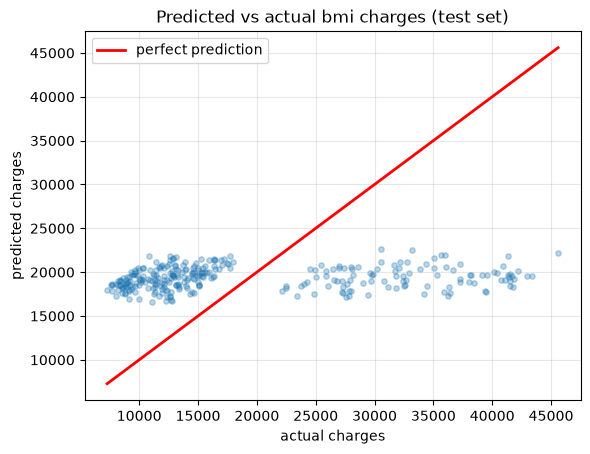

In [55]:
plt.scatter(y_test, predictions, alpha=0.3, s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linewidth=2, label="perfect prediction")
plt.xlabel("actual charges"); plt.ylabel("predicted charges")
plt.title("Predicted vs actual bmi charges (test set)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()